<a href="https://colab.research.google.com/github/CHRISJUMA-9/Tensor-Flow-Fundamentals/blob/main/Interactive_PyBullet_Environment_with_Object_Semantics_Objective.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Create Custom URDF Objects

##Create a storage folder

In [5]:
# This creates a directory in Colab where all custom URDF models
# (robot descriptions) will be saved.

import os

URDF_DIR = "/content/custom_urdf"
os.makedirs(URDF_DIR, exist_ok=True)

##Create Obstacle (wall/barrier)

In [6]:
# This URDF defines a solid red wall.
# It acts as a physical obstacle in the environment.

wall_urdf = """
<?xml version="1.0"?>
<robot name="wall_obstacle">

  <link name="wall_link">

    <!-- Physical properties (mass + inertia) -->
    <inertial>
      <origin xyz="0 0 0"/>
      <mass value="10"/>
      <inertia ixx="1" iyy="1" izz="1" ixy="0" ixz="0" iyz="0"/>
    </inertial>

    <!-- Visual appearance (what we see in simulation) -->
    <visual>
      <geometry>
        <box size="2 0.2 1"/>
      </geometry>
      <material name="red">
        <color rgba="1 0 0 1"/>
      </material>
    </visual>

    <!-- Collision shape (used for physics interaction) -->
    <collision>
      <geometry>
        <box size="2 0.2 1"/>
      </geometry>
    </collision>

  </link>
</robot>
"""

with open(f"{URDF_DIR}/wall_obstacle.urdf", "w") as f:
    f.write(wall_urdf)

## Create target (goal object)

In [7]:
# This green sphere represents a goal or pickup item
# that the robot should interact with.

target_urdf = """
<?xml version="1.0"?>
<robot name="target_object">

  <link name="target_link">

    <!-- Physical properties -->
    <inertial>
      <origin xyz="0 0 0"/>
      <mass value="1"/>
      <inertia ixx="0.1" iyy="0.1" izz="0.1" ixy="0" ixz="0" iyz="0"/>
    </inertial>

    <!-- Visual representation -->
    <visual>
      <geometry>
        <sphere radius="0.25"/>
      </geometry>
      <material name="green">
        <color rgba="0 1 0 1"/>
      </material>
    </visual>

    <!-- Collision shape -->
    <collision>
      <geometry>
        <sphere radius="0.25"/>
      </geometry>
    </collision>

  </link>
</robot>
"""

with open(f"{URDF_DIR}/target_object.urdf", "w") as f:
    f.write(target_urdf)

##Create landmark (reference object)

In [8]:
# This blue cube is used as a spatial reference point
# to help structure the environment.

landmark_urdf = """
<?xml version="1.0"?>
<robot name="landmark_object">

  <link name="landmark_link">

    <!-- Physical properties -->
    <inertial>
      <origin xyz="0 0 0"/>
      <mass value="2"/>
      <inertia ixx="0.2" iyy="0.2" izz="0.2" ixy="0" ixz="0" iyz="0"/>
    </inertial>

    <!-- Visual appearance -->
    <visual>
      <geometry>
        <box size="0.5 0.5 0.5"/>
      </geometry>
      <material name="blue">
        <color rgba="0 0 1 1"/>
      </material>
    </visual>

    <!-- Collision shape -->
    <collision>
      <geometry>
        <box size="0.5 0.5 0.5"/>
      </geometry>
    </collision>

  </link>
</robot>
"""

with open(f"{URDF_DIR}/landmark_object.urdf", "w") as f:
    f.write(landmark_urdf)

##Create Zone (semantic region)

In [9]:
# This is a flat yellow region representing a goal area.
# It is not just an object — it defines a spatial function.

zone_urdf = """
<?xml version="1.0"?>
<robot name="zone_object">

  <link name="zone_link">

    <!-- Physical properties -->
    <inertial>
      <origin xyz="0 0 0"/>
      <mass value="0.1"/>
      <inertia ixx="0.01" iyy="0.01" izz="0.01" ixy="0" ixz="0" iyz="0"/>
    </inertial>

    <!-- Visual representation (semi-transparent zone) -->
    <visual>
      <geometry>
        <box size="2 2 0.01"/>
      </geometry>
      <material name="yellow">
        <color rgba="1 1 0 0.4"/>
      </material>
    </visual>

    <!-- Collision shape -->
    <collision>
      <geometry>
        <box size="2 2 0.01"/>
      </geometry>
    </collision>

  </link>
</robot>
"""

with open(f"{URDF_DIR}/zone_object.urdf", "w") as f:
    f.write(zone_urdf)

##Load objects into PyBullet scene

In [10]:
# This starts the physics engine and loads all URDF objects
# into the simulation environment.

!pip install pybullet # Install pybullet
import pybullet as p
import pybullet_data

# Connect to PyBullet in headless mode (Colab requirement)
p.connect(p.DIRECT)

# Load default PyBullet assets (like plane.urdf)
p.setAdditionalSearchPath(pybullet_data.getDataPath())

# Set gravity for realistic physics
p.setGravity(0, 0, -9.8)

# Create ground plane
plane = p.loadURDF("plane.urdf")

# Load custom semantic objects into the scene
wall_id = p.loadURDF("/content/custom_urdf/wall_obstacle.urdf", [0, 2, 0.5])
target_id = p.loadURDF("/content/custom_urdf/target_object.urdf", [2, 0, 0.3])
landmark_id = p.loadURDF("/content/custom_urdf/landmark_object.urdf", [-2, 0, 0.25])
zone_id = p.loadURDF("/content/custom_urdf/zone_object.urdf", [0, -2, 0.01])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pybullet: filename=pybullet-3.2.7-cp312-cp312-linux_x86_64.whl size=99873463 sha256=ad1505d247010c52d986d3f1f5ec0f6e172f4d6d351c845d694c7f3e464c497b
  Stored in directory: /root/.cache/pip/wheels/72/95/1d/b336e5ee612ae9a019bfff4dc0bedd100ee6f0570db205fdf8
Successfully built pybullet


##Semantic mapping (meaning layer)

In [11]:
# Add Semantic Meaning to Objects
# This converts raw physics objects into meaningful entities.
# Each object now has a "role" that can be used for reasoning.

semantic_map = {
    wall_id: {
        "role": "obstacle",   # blocks movement
        "name": "wall"
    },
    target_id: {
        "role": "target",     # goal to reach
        "name": "goal_object"
    },
    landmark_id: {
        "role": "landmark",   # reference point
        "name": "reference_cube"
    },
    zone_id: {
        "role": "zone",       # goal region
        "name": "goal_area"
    }
}

#Step 2: Design a Structured Environment


##Structured environment setup

In [14]:
#This resets the simulation and prepares a warehouse-style scene
# with multiple semantic objects.

import time

# Restart physics engine
p.resetSimulation()

# Load assets
p.setAdditionalSearchPath(pybullet_data.getDataPath())

# Gravity
p.setGravity(0, 0, -9.8)

# Ground plane
plane = p.loadURDF("plane.urdf")

##Load warehouse walls (boundary structure)

In [15]:
# These define the physical limits of the environment

walls = []

walls.append(p.loadURDF("/content/custom_urdf/wall_obstacle.urdf", [0, 4, 0.5]))
walls.append(p.loadURDF("/content/custom_urdf/wall_obstacle.urdf", [0, -4, 0.5]))
walls.append(p.loadURDF("/content/custom_urdf/wall_obstacle.urdf", [4, 0, 0.5]))
walls.append(p.loadURDF("/content/custom_urdf/wall_obstacle.urdf", [-4, 0, 0.5]))

Add obstacles (warehouse blocks)

In [16]:
# Internal Obstacles (navigation difficulty)

obstacles = []

obstacles.append(p.loadURDF("/content/custom_urdf/wall_obstacle.urdf", [2, 2, 0.5]))
obstacles.append(p.loadURDF("/content/custom_urdf/wall_obstacle.urdf", [-2, -2, 0.5]))
obstacles.append(p.loadURDF("/content/custom_urdf/wall_obstacle.urdf", [2, -2, 0.5]))

##Add targets (goals)

In [17]:
# These represent items a robot should find or interact with

targets = []

targets.append(p.loadURDF("/content/custom_urdf/target_object.urdf", [3, 3, 0.3]))
targets.append(p.loadURDF("/content/custom_urdf/target_object.urdf", [-3, -3, 0.3]))

## Add Landmarks (Reference Points)

In [18]:
# Used for orientation and spatial awareness

landmarks = []

landmarks.append(p.loadURDF("/content/custom_urdf/landmark_object.urdf", [3, -3, 0.25]))
landmarks.append(p.loadURDF("/content/custom_urdf/landmark_object.urdf", [-3, 3, 0.25]))

##Add Goal Zone (Semantic Region)

In [19]:
# Represents success region in the warehouse task

zone = p.loadURDF("/content/custom_urdf/zone_object.urdf", [0, 0, 0.01])

##Create Semantic Map

In [20]:
# Semantic Layer (Meaning attached to objects)
# This makes the environment "interpretable"

semantic_map = {}

for w in walls:
    semantic_map[w] = {"role": "boundary_wall"}

for o in obstacles:
    semantic_map[o] = {"role": "obstacle"}

for t in targets:
    semantic_map[t] = {"role": "target"}

for l in landmarks:
    semantic_map[l] = {"role": "landmark"}

semantic_map[zone] = {"role": "goal_zone"}

#Step 3: Introduce Object Semantics

#Semantic object registry

In [21]:
# This dictionary acts as the "brain" of the environment.
# It maps each PyBullet object ID → semantic meaning (role + name)

semantic_registry = {}

##Helper function to register objects

In [22]:
# This function assigns semantic meaning to any object in the scene.
# It stores role (obstacle/target/landmark/zone) + human-readable name.

def register_object(obj_id, name, role):
    semantic_registry[obj_id] = {
        "name": name,
        "role": role
    }

##Load Objects AND Assign Semantics

In [23]:
# (Assumes Step 2 objects already exist in URDF folder)

wall1 = p.loadURDF("/content/custom_urdf/wall_obstacle.urdf", [0, 3, 0.5])
register_object(wall1, "north_wall", "obstacle")

wall2 = p.loadURDF("/content/custom_urdf/wall_obstacle.urdf", [0, -3, 0.5])
register_object(wall2, "south_wall", "obstacle")

target1 = p.loadURDF("/content/custom_urdf/target_object.urdf", [2, 2, 0.3])
register_object(target1, "pickup_item_1", "target")

target2 = p.loadURDF("/content/custom_urdf/target_object.urdf", [-2, -2, 0.3])
register_object(target2, "pickup_item_2", "target")

landmark1 = p.loadURDF("/content/custom_urdf/landmark_object.urdf", [3, -3, 0.25])
register_object(landmark1, "blue_marker", "landmark")

landmark2 = p.loadURDF("/content/custom_urdf/landmark_object.urdf", [-3, 3, 0.25])
register_object(landmark2, "green_marker", "landmark")

zone = p.loadURDF("/content/custom_urdf/zone_object.urdf", [0, 0, 0.01])
register_object(zone, "goal_zone", "zone")

##Programmatic Object Identification

In [24]:
# This shows how the system can "understand" what an object is.

def identify_object(obj_id):
    if obj_id in semantic_registry:
        info = semantic_registry[obj_id]
        return f"Object: {info['name']} | Role: {info['role']}"
    else:
        return "Unknown object"

##Demostration

In [25]:
# This proves that objects can be queried programmatically

for obj_id in semantic_registry:
    print(identify_object(obj_id))

Object: north_wall | Role: obstacle
Object: south_wall | Role: obstacle
Object: pickup_item_1 | Role: target
Object: pickup_item_2 | Role: target
Object: blue_marker | Role: landmark
Object: green_marker | Role: landmark
Object: goal_zone | Role: zone


##Query by Role (Advanced Semantic Reasoning)

In [26]:
# This allows the system to reason about categories

def get_objects_by_role(role):
    return [
        obj_id for obj_id, info in semantic_registry.items()
        if info["role"] == role
    ]

# Example usage:
print("Targets:", get_objects_by_role("target"))
print("Obstacles:", get_objects_by_role("obstacle"))

Targets: [15, 16]
Obstacles: [13, 14]


#Step 4: Camera-Based Scene Observation

##Setup (DIRECT mode reminder)

In [27]:
# We use DIRECT mode (no GUI window)
# and rely on virtual cameras for visualization.

import numpy as np
import matplotlib.pyplot as plt

p.setAdditionalSearchPath(pybullet_data.getDataPath())

# Ensure simulation is running in DIRECT mode
# (already connected in previous steps)

##Camera Rendering Function (Reusable)

In [28]:
# Captures an image from a specific viewpoint in PyBullet.

def render_scene_from_camera(eye, target):
    width = 640
    height = 480

    # Camera view (position + where it looks)
    view_matrix = p.computeViewMatrix(
        cameraEyePosition=eye,
        cameraTargetPosition=target,
        cameraUpVector=[0, 0, 1]
    )

    # Camera lens settings (field of view)
    projection_matrix = p.computeProjectionMatrixFOV(
        fov=60,
        aspect=width / height,
        nearVal=0.1,
        farVal=10
    )

    # Capture image from simulation
    _, _, rgb, _, _ = p.getCameraImage(
        width,
        height,
        view_matrix,
        projection_matrix
    )

    # Convert to display format
    img = np.array(rgb)
    img = img[:, :, :3]

    return img

##Camera Viewpoint 1 — Top-Down (Global Layout)

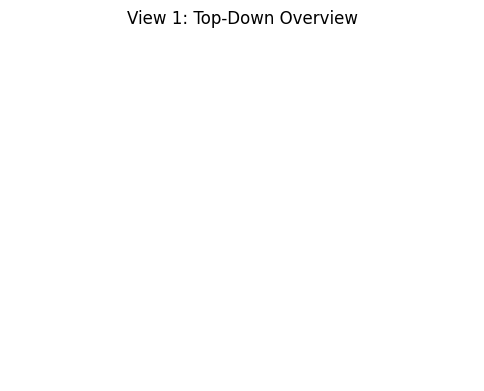

In [30]:
# Shows full warehouse structure and object placement.

view1 = render_scene_from_camera(
    eye=[0, 0, 8],       # high above the scene
    target=[0, 0, 0]     # looking at center
)

plt.figure(figsize=(6, 6))
plt.title("View 1: Top-Down Overview")
plt.imshow(view1)
plt.axis("off")
plt.show()

##Camera Viewpoint 2 — Side Perspective

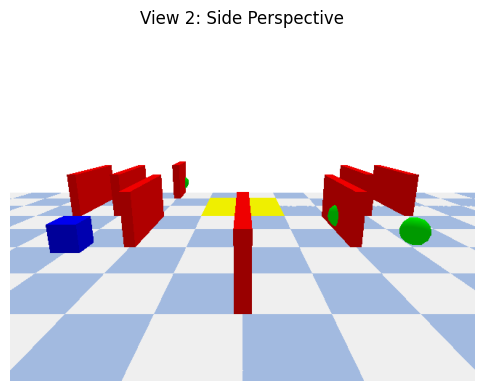

In [31]:
# Shows depth, obstacles, and spatial layout

view2 = render_scene_from_camera(
    eye=[8, 0, 2],       # side position
    target=[0, 0, 0]
)

plt.figure(figsize=(6, 6))
plt.title("View 2: Side Perspective")
plt.imshow(view2)
plt.axis("off")
plt.show()

##Camera Viewpoint 3 — Agent-Level View

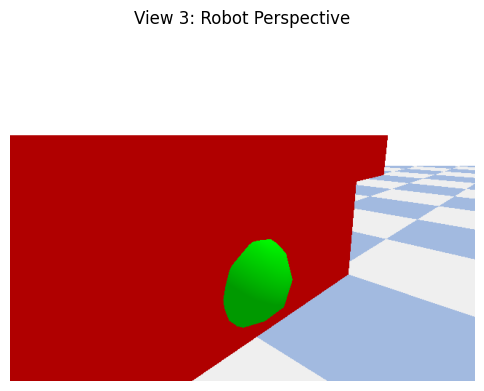

In [32]:
# Simulates what a robot would "see" in the environment

view3 = render_scene_from_camera(
    eye=[3, 3, 1],       # near ground level
    target=[0, 0, 0]
)

plt.figure(figsize=(6, 6))
plt.title("View 3: Robot Perspective")
plt.imshow(view3)
plt.axis("off")
plt.show()

#Step 5: Basic Interaction or Query Mechanism

##Basic Interaction or Query Mechanism

In [33]:
# We retrieve object positions from PyBullet
# and combine them with semantic roles.

def get_object_position(obj_id):
    # Returns current world position of an object
    pos, _ = p.getBasePositionAndOrientation(obj_id)
    return pos

##Query: Print All Objects with Roles + Positions

In [34]:
# QUERY 1: PRINT ALL OBJECTS WITH SEMANTIC INFO
# This shows how the system "understands" the environment

for obj_id, info in semantic_registry.items():
    pos = get_object_position(obj_id)

    print(
        f"Object: {info['name']} | "
        f"Role: {info['role']} | "
        f"Position: {pos}"
    )

Object: north_wall | Role: obstacle | Position: (0.0, 3.0, 0.5)
Object: south_wall | Role: obstacle | Position: (0.0, -3.0, 0.5)
Object: pickup_item_1 | Role: target | Position: (2.0, 2.0, 0.3)
Object: pickup_item_2 | Role: target | Position: (-2.0, -2.0, 0.3)
Object: blue_marker | Role: landmark | Position: (3.0, -3.0, 0.25)
Object: green_marker | Role: landmark | Position: (-3.0, 3.0, 0.25)
Object: goal_zone | Role: zone | Position: (0.0, 0.0, 0.01)


##Query: Find Nearest Object to a Point

In [35]:
import numpy as np

# QUERY 2: FIND NEAREST OBJECT
# This simulates robot perception:
# "What is closest to me?"

def distance(a, b):
    return np.linalg.norm(np.array(a) - np.array(b))

def nearest_object(reference_position):
    nearest_id = None
    min_dist = float("inf")

    for obj_id in semantic_registry:
        pos = get_object_position(obj_id)
        d = distance(reference_position, pos)

        if d < min_dist:
            min_dist = d
            nearest_id = obj_id

    return nearest_id, min_dist


# Example: robot at center
robot_pos = [0, 0, 0]

nearest_id, dist = nearest_object(robot_pos)

info = semantic_registry[nearest_id]

print("Nearest Object:")
print("Name:", info["name"])
print("Role:", info["role"])
print("Distance:", dist)

Nearest Object:
Name: goal_zone
Role: zone
Distance: 0.01


##Query: Detect All Targets

In [36]:
# QUERY 3: TARGET DETECTION
# Finds all objects with role = "target"

def detect_targets():
    targets = []

    for obj_id, info in semantic_registry.items():
        if info["role"] == "target":
            pos = get_object_position(obj_id)

            targets.append({
                "name": info["name"],
                "position": pos,
                "id": obj_id
            })

    return targets


targets_found = detect_targets()

print("Targets detected:")
for t in targets_found:
    print(t)

Targets detected:
{'name': 'pickup_item_1', 'position': (2.0, 2.0, 0.3), 'id': 15}
{'name': 'pickup_item_2', 'position': (-2.0, -2.0, 0.3), 'id': 16}


##Query: Highlight Object Categories (Logical Highlighting)

In [37]:
# QUERY 4: CATEGORY HIGHLIGHTING (LOGICAL)
# We don't change visuals (since Colab is headless),
# but we group objects by role.

categories = {
    "obstacle": [],
    "target": [],
    "landmark": [],
    "zone": []
}

for obj_id, info in semantic_registry.items():
    role = info["role"]

    if role in categories:
        categories[role].append(info["name"])


print("Object Categories:")
for role, items in categories.items():
    print(role.upper(), ":", items)

Object Categories:
OBSTACLE : ['north_wall', 'south_wall']
TARGET : ['pickup_item_1', 'pickup_item_2']
LANDMARK : ['blue_marker', 'green_marker']
ZONE : ['goal_zone']


#Visualisation

##Camera Rendering Function

In [39]:
# This function captures the PyBullet scene as an image
# and prepares it for display using Matplotlib.

def render_camera():
    width = 640
    height = 480

    # Camera position (adjustable viewpoint)
    view_matrix = p.computeViewMatrix(
        cameraEyePosition=[4, 4, 4],
        cameraTargetPosition=[0, 0, 0],
        cameraUpVector=[0, 0, 1]
    )

    # Camera lens settings
    projection_matrix = p.computeProjectionMatrixFOV(
        fov=60,
        aspect=width / height,
        nearVal=0.1,
        farVal=10
    )

    # Capture image from simulation
    _, _, rgb, _, _ = p.getCameraImage(
        width,
        height,
        view_matrix,
        projection_matrix
    )

    # Convert to display format
    img = np.array(rgb)[:, :, :3]

    return img

##Display Single View of Scene

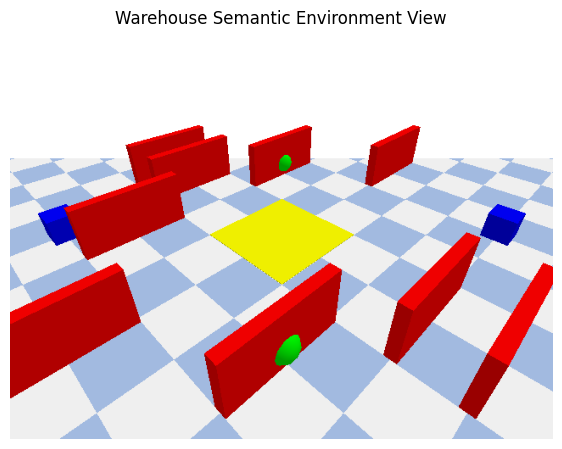

In [40]:
# DISPLAY SINGLE VIEW
# Shows the full semantic environment in one frame

img = render_camera()

plt.figure(figsize=(7, 7))
plt.title("Warehouse Semantic Environment View")
plt.imshow(img)
plt.axis("off")
plt.show()

##Multiple View of Scene

###View 1 — Top Overview

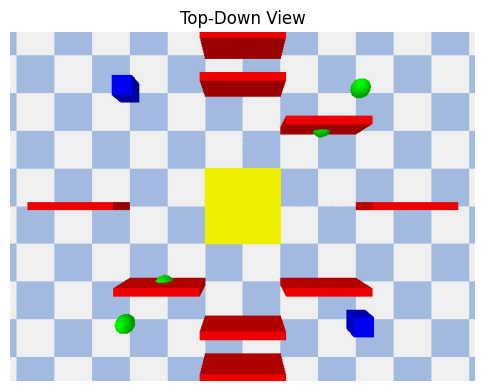

In [41]:
# VIEW 1: TOP-DOWN STRUCTURE VIEW

img1 = p.getCameraImage(
    640, 480,
    p.computeViewMatrix([0, 0, 8], [0, 0, 0], [0, 1, 0]),
    p.computeProjectionMatrixFOV(60, 640/480, 0.1, 10)
)[2]

plt.figure(figsize=(6, 6))
plt.title("Top-Down View")
plt.imshow(np.array(img1)[:, :, :3])
plt.axis("off")
plt.show()

###View 2 — Side Perspective

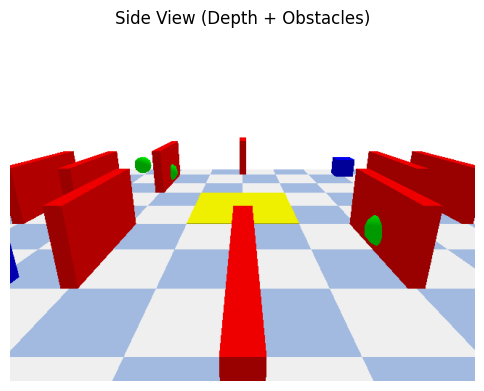

In [42]:
# VIEW 2: SIDE PERSPECTIVE

img2 = p.getCameraImage(
    640, 480,
    p.computeViewMatrix([6, 0, 2], [0, 0, 0], [0, 0, 1]),
    p.computeProjectionMatrixFOV(60, 640/480, 0.1, 10)
)[2]

plt.figure(figsize=(6, 6))
plt.title("Side View (Depth + Obstacles)")
plt.imshow(np.array(img2)[:, :, :3])
plt.axis("off")
plt.show()

###View 3 — Robot-Level View

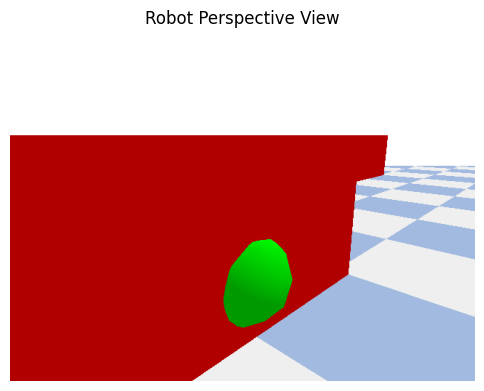

In [43]:
# VIEW 3: ROBOT-LEVEL VIEW

img3 = p.getCameraImage(
    640, 480,
    p.computeViewMatrix([3, 3, 1], [0, 0, 0], [0, 0, 1]),
    p.computeProjectionMatrixFOV(60, 640/480, 0.1, 10)
)[2]

plt.figure(figsize=(6, 6))
plt.title("Robot Perspective View")
plt.imshow(np.array(img3)[:, :, :3])
plt.axis("off")
plt.show()